# Exploratory Data Analysis — Smart Energy Consumption Prediction

This notebook explores the **UCI Appliances Energy Prediction** dataset
(Candanedo, Feldheim & Deramaix, 2017): 19,735 readings taken every 10
minutes over 4.5 months in a low-energy house in Stambruges, Belgium,
combining indoor ZigBee sensor readings with outdoor weather data from
Chievres Airport.

**Goal of this notebook:** understand the data well enough to justify the
cleaning and feature engineering decisions made in `src/preprocessing.py`
and `src/feature_engineering.py`, before any modeling happens.


In [1]:
import sys
sys.path.insert(0, '../src')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from preprocessing import load_data

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

df = load_data("../data/energydata_complete.csv")
df.head()


2026-06-20 12:54:15,430 | INFO | Loaded 19735 rows, 29 columns from ../data/energydata_complete.csv


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## 1. Dataset Overview

29 columns: a timestamp, the target (`Appliances`, in Wh), a `lights`
column (a secondary, much smaller energy load), 9 indoor temperature/humidity
sensor pairs (T1-T9, RH_1-RH_9), 6 outdoor weather columns, and two random
noise columns (`rv1`, `rv2`) the dataset authors deliberately included to
test whether models could learn to ignore irrelevant features.

In [2]:
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Duration: {(df['date'].max() - df['date'].min()).days} days")
df.dtypes


Rows: 19,735
Columns: 29
Date range: 2016-01-11 17:00:00 to 2016-05-27 18:00:00
Duration: 137 days


date           datetime64[us]
Appliances              int64
lights                  int64
T1                    float64
RH_1                  float64
T2                    float64
RH_2                  float64
T3                    float64
RH_3                  float64
T4                    float64
RH_4                  float64
T5                    float64
RH_5                  float64
T6                    float64
RH_6                  float64
T7                    float64
RH_7                  float64
T8                    float64
RH_8                  float64
T9                    float64
RH_9                  float64
T_out                 float64
Press_mm_hg           float64
RH_out                float64
Windspeed             float64
Visibility            float64
Tdewpoint             float64
rv1                   float64
rv2                   float64
dtype: object

In [3]:
df[["Appliances", "lights", "T1", "RH_1", "T_out", "RH_out"]].describe().round(2)


,Appliances,lights,T1,RH_1,T_out,RH_out
count,19735.00,19735.00,19735.00,19735.00,19735.00,19735.00
mean,97.69,3.80,21.69,40.26,7.41,79.75
std,102.52,7.94,1.61,3.98,5.32,14.90
min,10.00,0.00,16.79,27.02,-5.00,24.00
25%,50.00,0.00,20.76,37.33,3.67,70.33
50%,60.00,0.00,21.60,39.66,6.92,83.67
75%,100.00,0.00,22.60,43.07,10.41,91.67
max,1080.00,70.00,26.26,63.36,26.10,100.00


## 2. Missing Value Analysis

This dataset is known to be very clean (it comes from a controlled
research deployment), but we check anyway rather than assume.

In [4]:
missing = df.isna().sum()
print(f"Total missing cells: {missing.sum()}")
missing[missing > 0]


Total missing cells: 0


Series([], dtype: int64)

## 3. Target Variable: `Appliances`

This is heavily right-skewed — most 10-minute intervals draw a modest,
fairly constant baseline load, with occasional large spikes (likely from
high-draw appliances like an oven, kettle, or washing machine cycling on).
That skew is exactly why **RMSE** (which penalizes large errors more) and
**MAE** (which is more robust to the long tail) tell a meaningfully
different story for this target, and why we report both later.

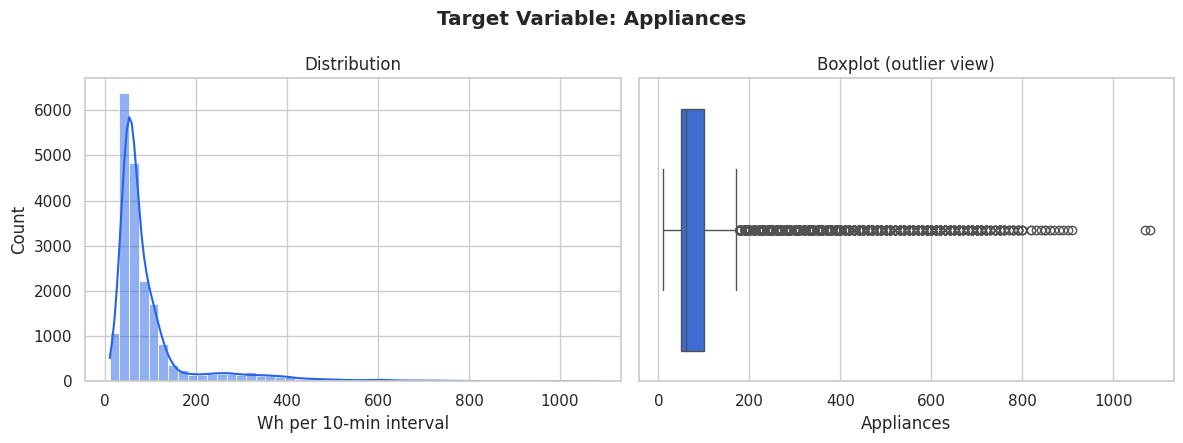

Mean: 97.7 Wh | Median: 60.0 Wh | Std: 102.5 Wh | Max: 1080 Wh


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["Appliances"], bins=50, kde=True, ax=axes[0], color="#2563eb")
axes[0].set_title("Distribution")
axes[0].set_xlabel("Wh per 10-min interval")

sns.boxplot(x=df["Appliances"], ax=axes[1], color="#2563eb")
axes[1].set_title("Boxplot (outlier view)")
fig.suptitle("Target Variable: Appliances", fontweight="bold")
fig.tight_layout()
plt.show()

print(f"Mean: {df['Appliances'].mean():.1f} Wh | Median: {df['Appliances'].median():.1f} Wh | "
      f"Std: {df['Appliances'].std():.1f} Wh | Max: {df['Appliances'].max():.0f} Wh")


## 4. Correlation Matrix

Most of the room temperature sensors (T1-T9) are strongly correlated with
each other — unsurprising, since heat moves between rooms in the same
house. This redundancy is exactly why we later engineer `Temp_avg` and
`Temp_spread` as compressed summaries instead of feeding all 9 raw
temperature columns independently into a linear model.

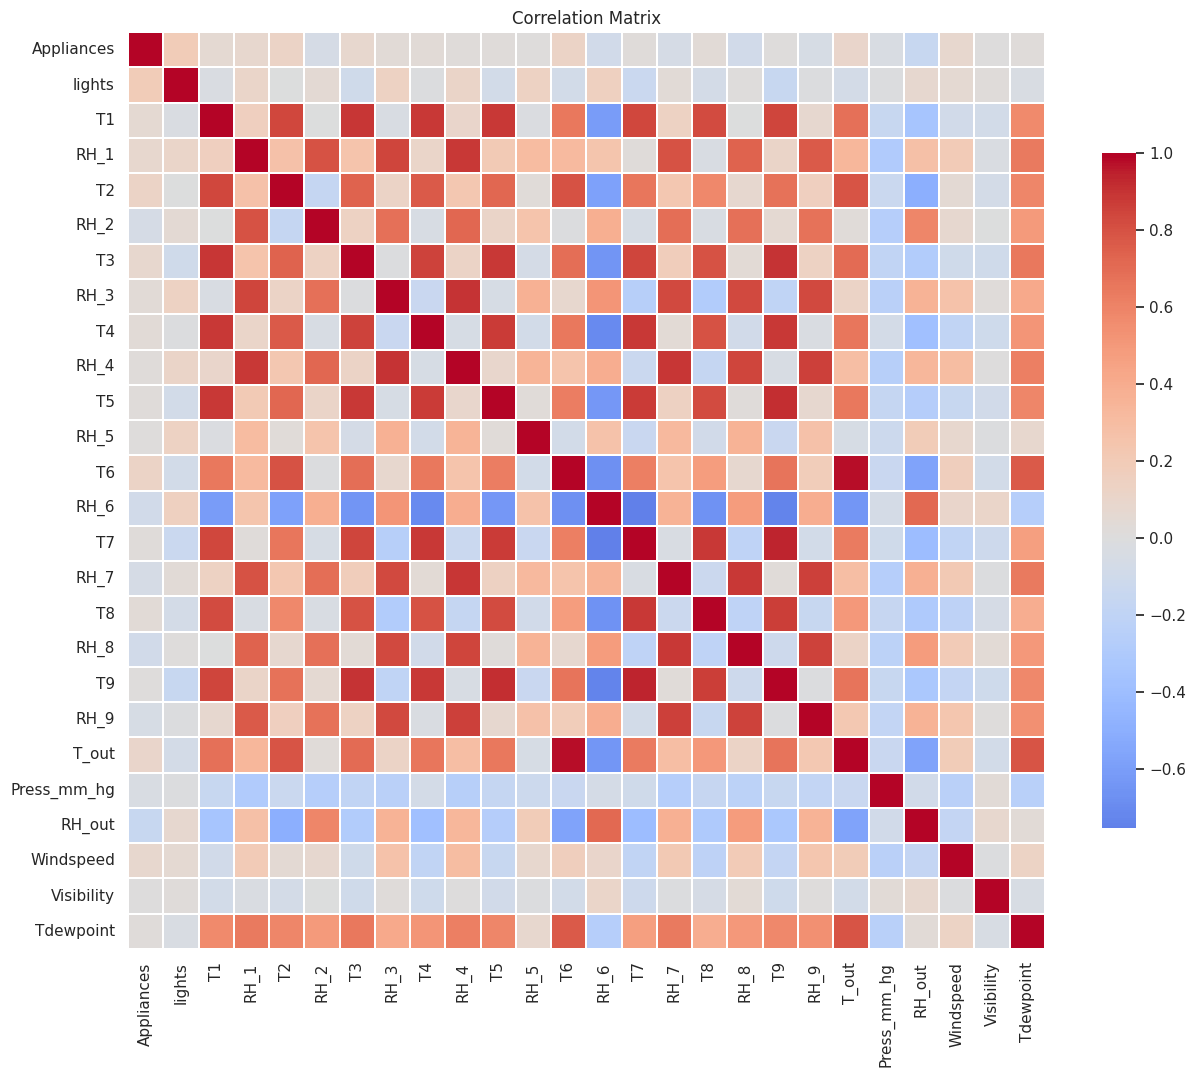

In [6]:
numeric = df.select_dtypes(include=[np.number]).drop(columns=["rv1", "rv2"])
corr = numeric.corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, linewidths=0.3, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlation Matrix")
fig.tight_layout()
plt.show()


In [7]:
target_corr = corr["Appliances"].drop("Appliances").sort_values(key=abs, ascending=False)
print("Features most correlated with Appliances:")
target_corr.head(10)


Features most correlated with Appliances:


lights       0.197278
RH_out      -0.152282
T2           0.120073
T6           0.117638
T_out        0.099155
RH_8        -0.094039
Windspeed    0.087122
RH_1         0.086031
T3           0.085060
RH_6        -0.083178
Name: Appliances, dtype: float64

**Observation:** no single feature is strongly correlated with `Appliances`
on its own (the strongest, `lights`, is only ~0.20). This tells us upfront
that this is a genuinely hard regression problem — appliance use is driven
mostly by human behavior (cooking, laundry, what's plugged in) that isn't
directly observable from ambient temperature and humidity. We should expect
modest R² scores even from a well-tuned model, and should not over-engineer
around a single feature.

## 5. Feature Distributions: Temperature, Humidity & Weather

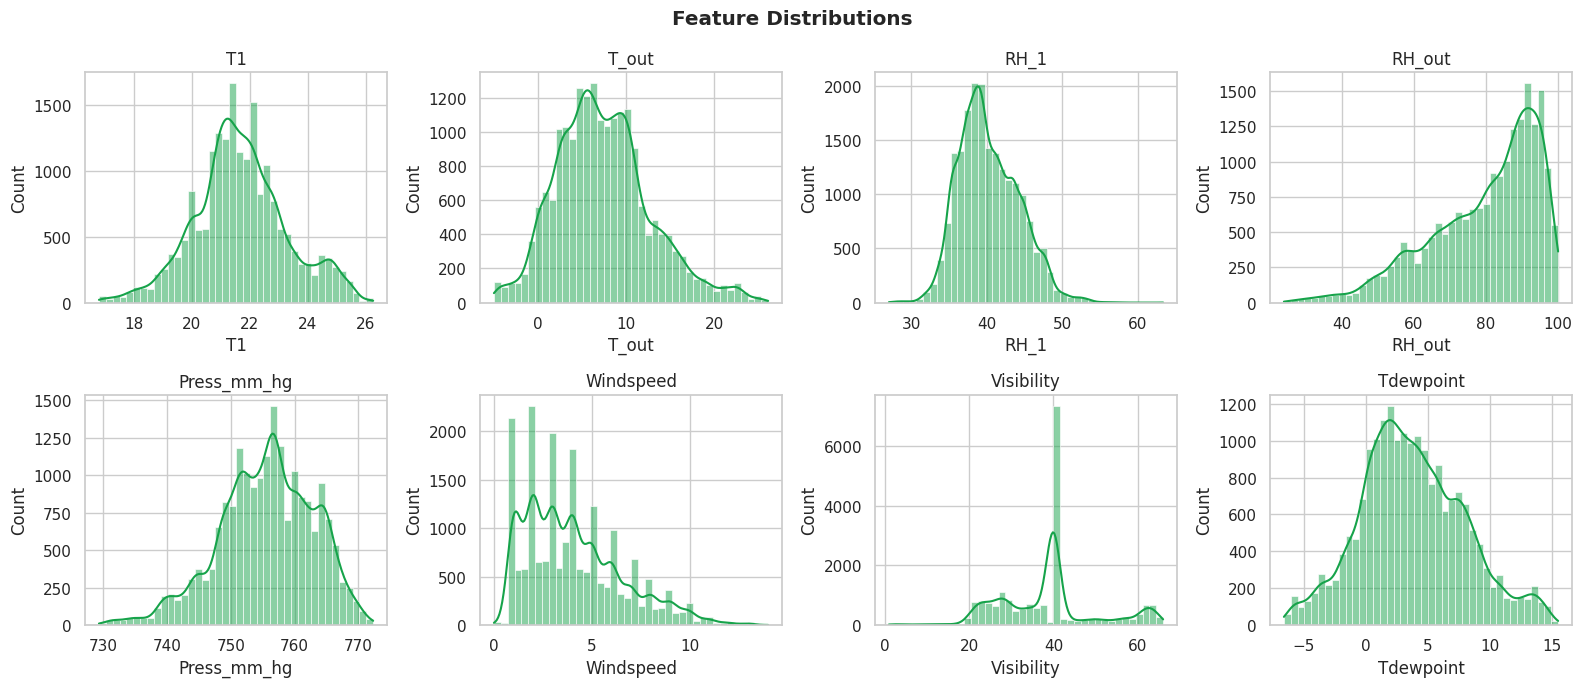

In [8]:
cols = ["T1", "T_out", "RH_1", "RH_out", "Press_mm_hg", "Windspeed", "Visibility", "Tdewpoint"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color="#16a34a")
    ax.set_title(col)
fig.suptitle("Feature Distributions", fontweight="bold")
fig.tight_layout()
plt.show()


## 6. Boxplots: Temperature Spread Across Rooms

Room T6 (likely an outdoor-facing or unheated space, given it tracks close
to outdoor temperature) stands out as colder and more variable than the
other rooms — a useful sanity check that the sensor placement makes
physical sense.

2026-06-20 12:54:18,186 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-20 12:54:18,270 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


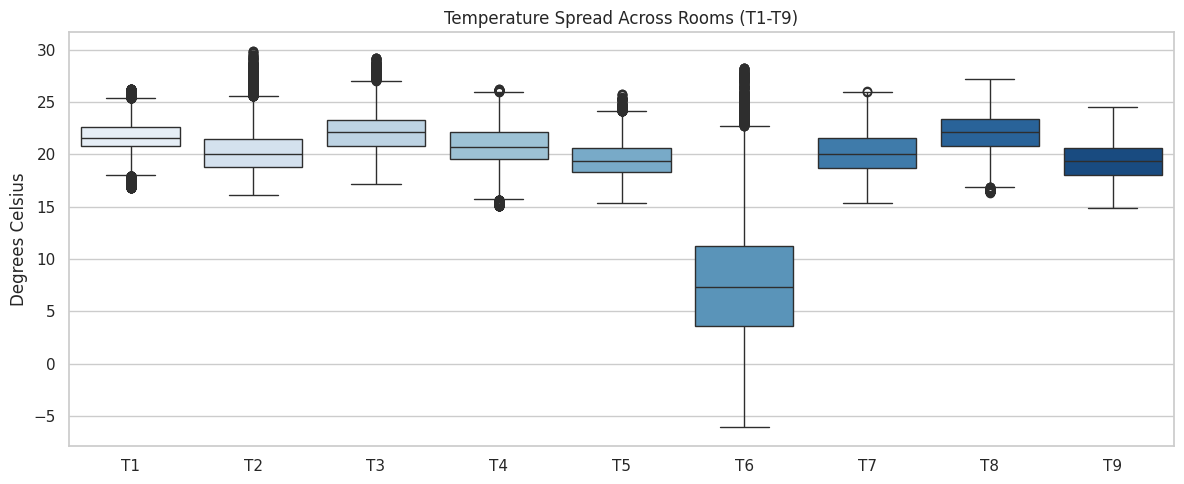

In [9]:
temp_cols = [c for c in df.columns if c.startswith("T") and c[1:].isdigit()]
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df[temp_cols], ax=ax, palette="Blues")
ax.set_title("Temperature Spread Across Rooms (T1-T9)")
ax.set_ylabel("Degrees Celsius")
fig.tight_layout()
plt.show()


## 7. Scatter Plots: Candidate Relationships with the Target

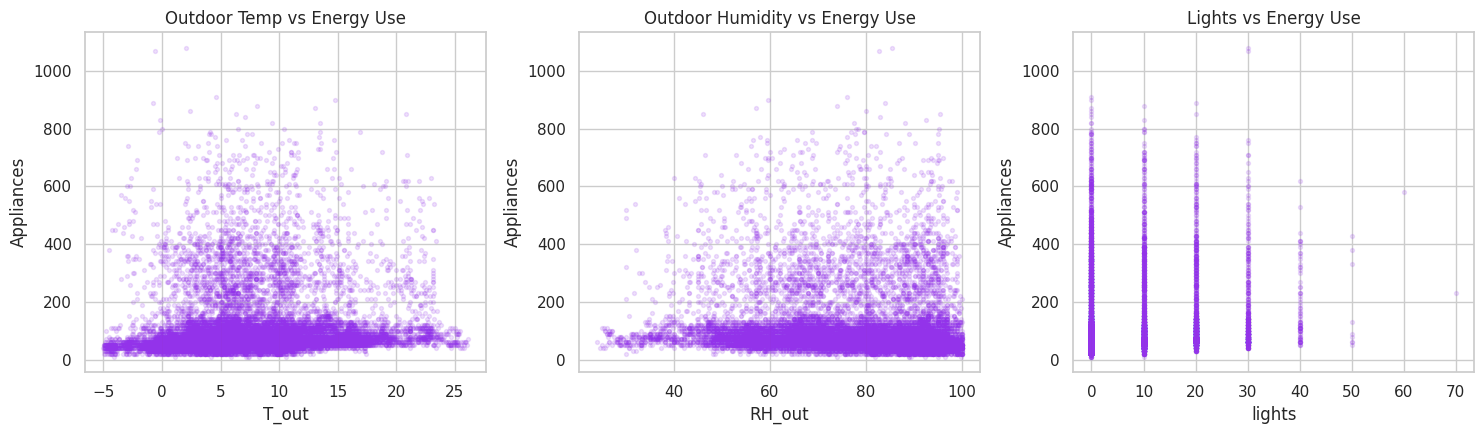

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
pairs = [("T_out", "Appliances", "Outdoor Temp vs Energy Use"),
         ("RH_out", "Appliances", "Outdoor Humidity vs Energy Use"),
         ("lights", "Appliances", "Lights vs Energy Use")]
for ax, (x, y, title) in zip(axes, pairs):
    ax.scatter(df[x], df[y], alpha=0.15, s=8, color="#9333ea")
    ax.set_xlabel(x); ax.set_ylabel(y); ax.set_title(title)
fig.tight_layout()
plt.show()


## 8. Time-of-Day Pattern

This is the single most useful insight in the whole EDA: appliance use
follows a clear daily rhythm, low overnight, rising through the morning,
and peaking sharply around 6-7pm (dinner / evening household activity).
This is exactly why `Hour` (and its cyclical sine/cosine encoding) becomes
one of the most important engineered features in `src/feature_engineering.py`.

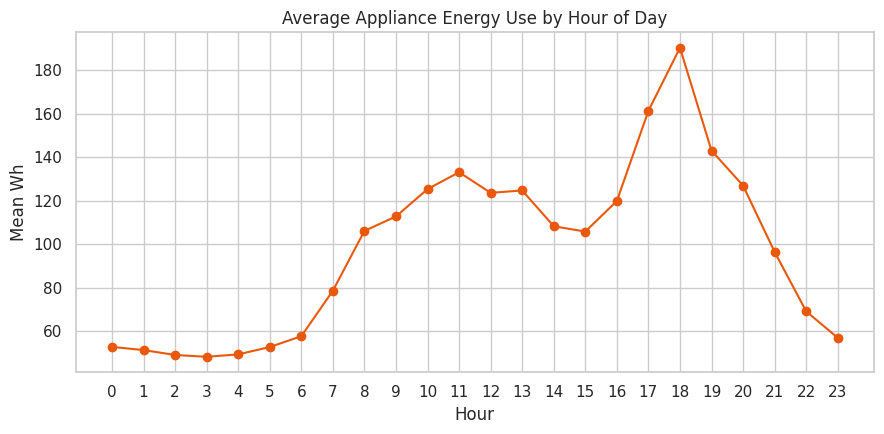

In [11]:
hourly = df.assign(Hour=df["date"].dt.hour).groupby("Hour")["Appliances"].mean()
fig, ax = plt.subplots(figsize=(9, 4.5))
hourly.plot(kind="line", marker="o", ax=ax, color="#ea580c")
ax.set_title("Average Appliance Energy Use by Hour of Day")
ax.set_xlabel("Hour"); ax.set_ylabel("Mean Wh")
ax.set_xticks(range(0, 24))
fig.tight_layout()
plt.show()


## 9. Summary of EDA Findings

1. The dataset is clean — zero missing values, no major data-quality issues beyond a handful of statistical outliers in `Appliances` and `lights` (handled later via capping, not deletion).
2. `Appliances` is strongly right-skewed with a long tail of high-draw events — both MAE and RMSE are reported during evaluation to capture this honestly.
3. No single raw feature correlates strongly with the target (max |r| ≈ 0.20) — this is a behavior-driven target, not a simple physics-driven one, so feature engineering (especially time-of-day) matters more than any one weather sensor.
4. There is a strong, exploitable daily usage rhythm peaking in the evening — `Hour`, `Hour_sin`/`Hour_cos`, and `DayPeriod` are engineered directly from this finding.
5. The 9 room temperature/humidity sensors are highly inter-correlated — aggregated into `Temp_avg`/`Temp_spread` and `RH_avg`/`RH_spread` to reduce redundancy.

These findings directly motivate the design of `src/feature_engineering.py` and the model choices compared in `src/train.py`.